<h1><b>FAKE NEWS DETECTION - EXPLORATORY DATA ANALYSIS (EDA)

<h2><b> 1. IMPORT LIBRARIES

In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords

# 2. DOWNLOAD NLTK RESOURCES

In [4]:

nltk.download("punkt")
nltk.download("stopwords")


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 3. LOAD DATASET

In [5]:



fake = pd.read_csv(
    "Fake.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)

# Load Real News Dataset


true = pd.read_csv(
    "True.csv",
    encoding="utf-8",
    engine="python",
    on_bad_lines="skip"
)


print("\nFake Dataset Shape:", fake.shape)
print("Real Dataset Shape:", true.shape)



Fake Dataset Shape: (23481, 4)
Real Dataset Shape: (21417, 4)


# 4. CREATE TARGET LABEL

In [6]:


# 0 = Fake News
# 1 = Real News

fake["label"] = 0
true["label"] = 1

# 5. COMBINE DATASETS

In [7]:

df = pd.concat(
    [fake, true],
    ignore_index=True
)


print("\nCombined Dataset Shape:", df.shape)


Combined Dataset Shape: (44898, 5)


# 6. DISPLAY COLUMN NAMES

In [8]:

print("\nDataset Columns:")
print(df.columns.tolist())



Dataset Columns:
['title', 'text', 'subject', 'date', 'label']


# 7. CHECK REQUIRED COLUMNS

In [9]:


required_columns = [
    "title",
    "text",
    "subject",
    "date",
    "label"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("\nERROR: Missing Columns:")
    print(missing_columns)

else:
    print("\nAll required columns are available.")



All required columns are available.


# 8. BASIC DATASET INFORMATION

In [10]:


print("\nDataset Shape:")
print(df.shape)

print("\nDataset Info:")
df.info()


Dataset Shape:
(44898, 5)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
 4   label    44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 1.7+ MB


# 9. FIRST FIVE RECORDS

In [11]:

print("\nFirst 5 Records:")
print(df.head())



First 5 Records:
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  label  
0  December 31, 2017      0  
1  December 31, 2017      0  
2  December 30, 2017      0  
3  December 29, 2017      0  
4  December 25, 2017      0  


# 10. MISSING VALUES

In [12]:

missing_values = df.isnull().sum()

print(missing_values)

title      0
text       0
subject    0
date       0
label      0
dtype: int64


# 11. DUPLICATE RECORDS

In [13]:

duplicate_count = df.duplicated().sum()

print("Number of Duplicate Records:", duplicate_count)


Number of Duplicate Records: 209


# 12. REMOVE DUPLICATES

In [14]:


df = df.drop_duplicates().reset_index(drop=True)

print(
    "Dataset Shape After Removing Duplicates:",
    df.shape
)


Dataset Shape After Removing Duplicates: (44689, 5)


# 13. HANDLE MISSING TEXT VALUES

In [15]:
df["title"] = df["title"].fillna("")
df["text"] = df["text"].fillna("")
df["subject"] = df["subject"].fillna("Unknown")
df["date"] = df["date"].fillna("")

# 14. CLASS DISTRIBUTION

In [16]:


class_counts = df["label"].value_counts().sort_index()

print("\nClass Counts:")
print(class_counts)

class_percentage = (
    df["label"]
    .value_counts(normalize=True)
    .sort_index() * 100
)

print("\nClass Percentage:")
print(class_percentage)


Class Counts:
label
0    23478
1    21211
Name: count, dtype: int64

Class Percentage:
label
0    52.536418
1    47.463582
Name: proportion, dtype: float64


# 15. CLASS DISTRIBUTION PLOT

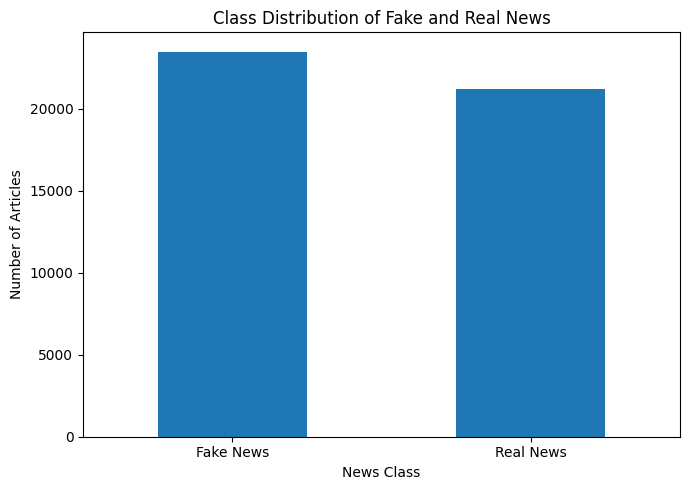

In [17]:

plt.figure(figsize=(7, 5))

class_counts.plot(
    kind="bar"
)

plt.xticks(
    [0, 1],
    ["Fake News", "Real News"],
    rotation=0
)

plt.title("Class Distribution of Fake and Real News")
plt.xlabel("News Class")
plt.ylabel("Number of Articles")

plt.tight_layout()
plt.show()


# 16. SUBJECT DISTRIBUTION

In [18]:


subject_counts = df["subject"].value_counts()

print(subject_counts)


subject
politicsNews       11220
worldnews           9991
News                9050
politics            6838
left-news           4459
Government News     1570
US_News              783
Middle-east          778
Name: count, dtype: int64


# 17. SUBJECT DISTRIBUTION PLOT

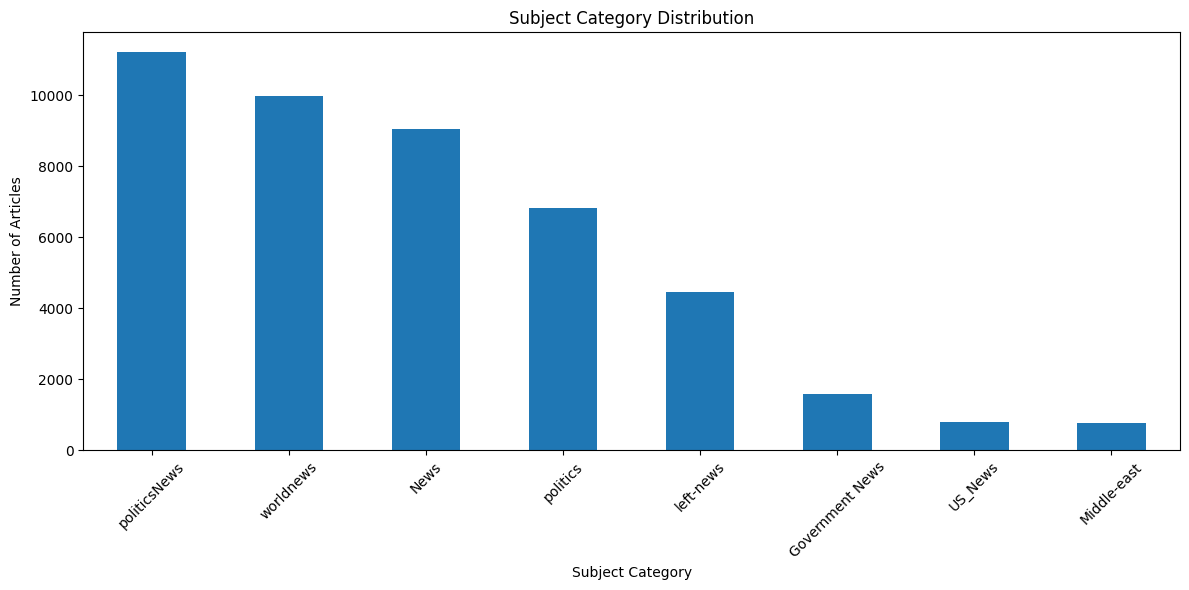

In [19]:


plt.figure(figsize=(12, 6))

subject_counts.plot(
    kind="bar"
)

plt.title("Subject Category Distribution")
plt.xlabel("Subject Category")
plt.ylabel("Number of Articles")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 18. DATE PROCESSING

In [20]:

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# 19. EXTRACT YEAR AND MONTH

In [21]:


df["year"] = df["date"].dt.year

df["month"] = df["date"].dt.month


# 20. TEMPORAL ANALYSIS - YEAR

In [22]:

year_counts = (
    df["year"]
    .value_counts()
    .sort_index()
)

print("\nArticles Published by Year:")
print(year_counts)



Articles Published by Year:
year
2015.0     338
2016.0    7077
2017.0    4453
Name: count, dtype: int64


# 21. ARTICLES BY YEAR PLOT

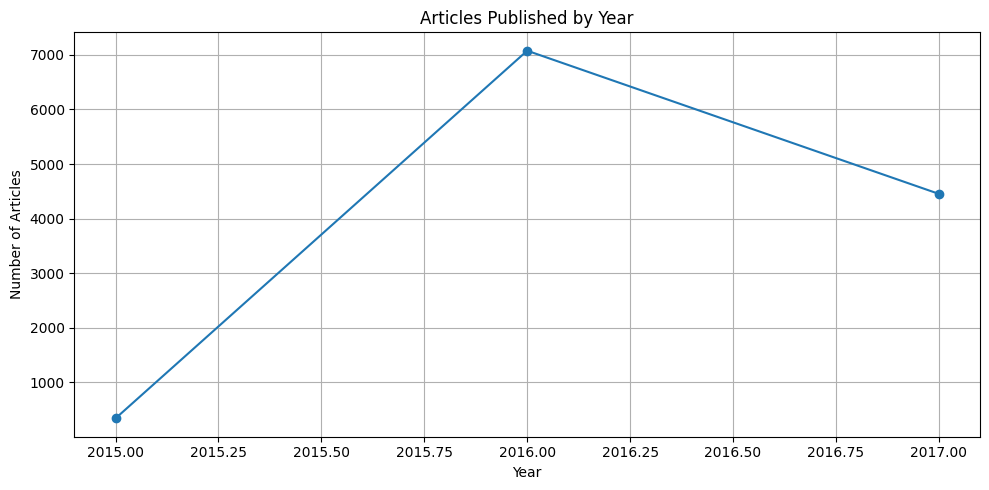

In [23]:

plt.figure(figsize=(10, 5))

year_counts.plot(
    kind="line",
    marker="o"
)

plt.title("Articles Published by Year")
plt.xlabel("Year")
plt.ylabel("Number of Articles")

plt.grid(True)

plt.tight_layout()
plt.show()


# 22. TITLE LENGTH FEATURES

In [24]:
df["title_char_count"] = (
    df["title"]
    .astype(str)
    .apply(len)
)


df["title_word_count"] = (
    df["title"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)


# 23. AVERAGE TITLE LENGTH BY CLASS

In [25]:


title_length_summary = (
    df.groupby("label")
    [
        [
            "title_char_count",
            "title_word_count"
        ]
    ]
    .mean()
)

print(title_length_summary)

       title_char_count  title_word_count
label                                    
0             94.194054         14.732388
1             64.658291          9.951582


# 24. TITLE LENGTH DISTRIBUTION

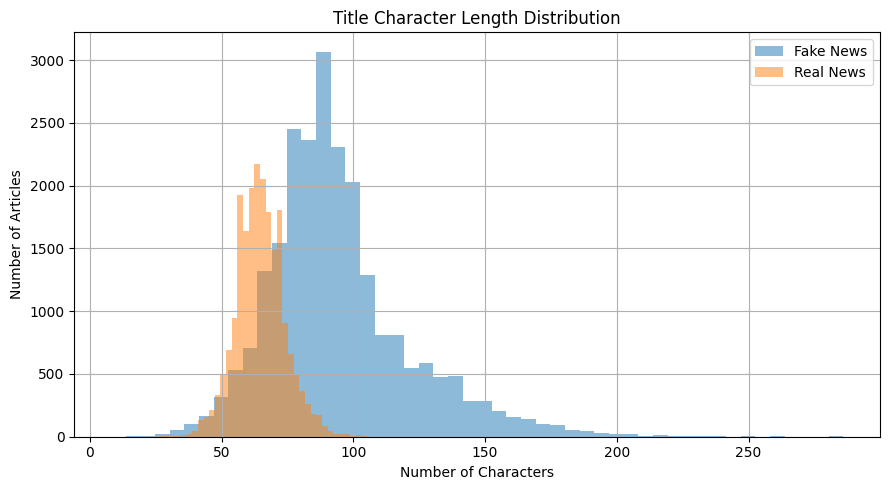

In [26]:

plt.figure(figsize=(9, 5))

for label, name in zip(
    [0, 1],
    ["Fake News", "Real News"]
):

    df[
        df["label"] == label
    ]["title_char_count"].hist(
        bins=50,
        alpha=0.5,
        label=name
    )


plt.legend()

plt.title(
    "Title Character Length Distribution"
)

plt.xlabel(
    "Number of Characters"
)

plt.ylabel(
    "Number of Articles"
)

plt.tight_layout()
plt.show()

# 25. TEXT LENGTH FEATURES

In [27]:

df["text_char_count"] = (
    df["text"]
    .astype(str)
    .apply(len)
)


df["word_count"] = (
    df["text"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)


# 26. AVERAGE TEXT LENGTH BY CLASS

In [28]:


text_length_summary = (
    df.groupby("label")
    [
        [
            "text_char_count",
            "word_count"
        ]
    ]
    .mean()
)

print(text_length_summary)

       text_char_count  word_count
label                             
0          2547.555882  423.224167
1          2378.042337  384.757484


# 27. WORD COUNT DISTRIBUTION

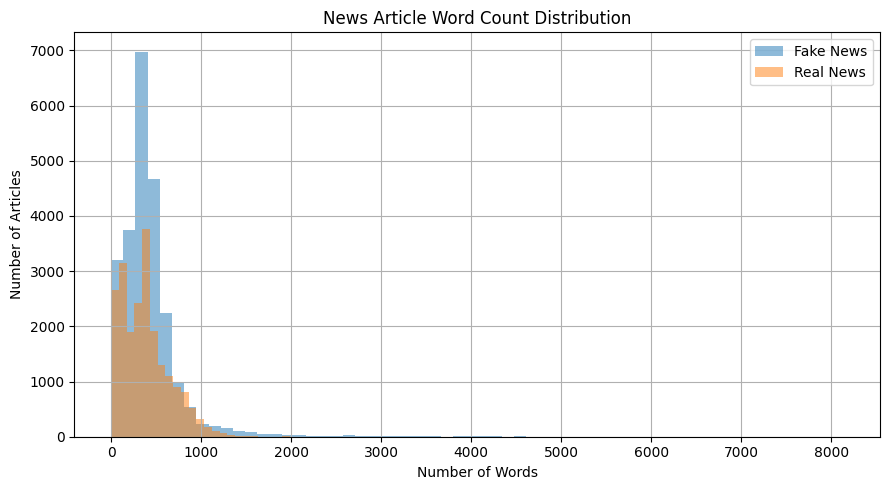

In [29]:


plt.figure(figsize=(9, 5))

for label, name in zip(
    [0, 1],
    ["Fake News", "Real News"]
):

    df[
        df["label"] == label
    ]["word_count"].hist(
        bins=60,
        alpha=0.5,
        label=name
    )


plt.legend()

plt.title(
    "News Article Word Count Distribution"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Number of Articles"
)

plt.tight_layout()
plt.show()

# 28. PUNCTUATION ANALYSIS

In [30]:

df["exclamation_count"] = (
    df["text"]
    .astype(str)
    .apply(
        lambda x: x.count("!")
    )
)


df["question_count"] = (
    df["text"]
    .astype(str)
    .apply(
        lambda x: x.count("?")
    )
)


# 29. PUNCTUATION SUMMARY

In [31]:


punctuation_summary = (
    df.groupby("label")
    [
        [
            "exclamation_count",
            "question_count"
        ]
    ]
    .mean()
)

print(punctuation_summary)

       exclamation_count  question_count
label                                   
0               0.722847        1.205682
1               0.062090        0.100325


# 30. UPPERCASE RATIO

In [32]:


def uppercase_ratio(text):

    text = str(text)

    # Keep only alphabetic characters
    letters = [
        char for char in text
        if char.isalpha()
    ]

    if len(letters) == 0:
        return 0

    uppercase_letters = sum(
        1
        for char in letters
        if char.isupper()
    )

    return uppercase_letters / len(letters)


df["uppercase_ratio"] = (
    df["text"]
    .apply(uppercase_ratio)
)


# 31. UPPERCASE RATIO SUMMARY

In [33]:


uppercase_summary = (
    df.groupby("label")
    ["uppercase_ratio"]
    .mean()
)

print(uppercase_summary)

label
0    0.057309
1    0.052020
Name: uppercase_ratio, dtype: float64


# 32. SUBJECT VS CLASS

In [34]:


subject_class = pd.crosstab(
    df["subject"],
    df["label"]
)

# Rename columns
subject_class.columns = [
    "Fake News",
    "Real News"
]

print(subject_class)


                 Fake News  Real News
subject                              
Government News       1570          0
Middle-east            778          0
News                  9050          0
US_News                783          0
left-news             4459          0
politics              6838          0
politicsNews             0      11220
worldnews                0       9991


# 33. SUBJECT VS CLASS PLOT

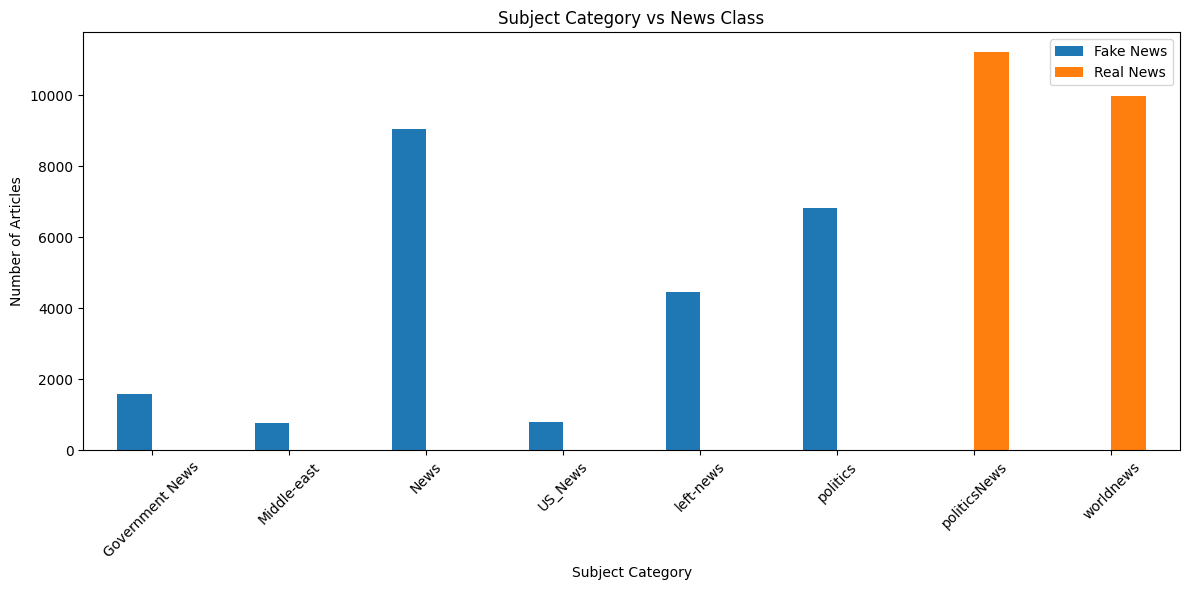

In [35]:


subject_class.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Subject Category vs News Class"
)

plt.xlabel(
    "Subject Category"
)

plt.ylabel(
    "Number of Articles"
)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 34. STOPWORDS

In [36]:
stop_words = set(
    stopwords.words("english")
)


# 35. TOP WORDS FUNCTION

In [37]:



def get_top_words(
    text_series,
    n=20
):

    words = []

    for text in text_series:

        # Convert to lowercase
        text = str(text).lower()

        # Split text
        tokens = text.split()

        # Clean punctuation
        tokens = [
            word.strip(
                ".,!?;:\"'()[]{}<>"
            )
            for word in tokens
        ]

        # Keep alphabetic words
        # Remove stopwords
        tokens = [
            word
            for word in tokens
            if word.isalpha()
            and word not in stop_words
            and len(word) > 2
        ]

        words.extend(tokens)

    return Counter(
        words
    ).most_common(n)

# TOP WORDS - FAKE NEWS and REAL NEWS

[('trump', 73291), ('said', 31005), ('people', 25937), ('president', 25463), ('would', 23419), ('one', 22858), ('clinton', 17945), ('obama', 17746), ('like', 17593), ('donald', 17098), ('also', 15221), ('new', 14135), ('news', 14087), ('even', 13655), ('hillary', 13496), ('white', 12762), ('time', 12664), ('state', 12494), ('via', 11140), ('media', 10976)]
[('said', 97822), ('trump', 41580), ('would', 31062), ('reuters', 28010), ('president', 24949), ('state', 18347), ('government', 17578), ('new', 16554), ('house', 16146), ('states', 15832), ('also', 15735), ('united', 15345), ('republican', 15185), ('people', 14413), ('told', 14070), ('could', 13475), ('last', 12438), ('one', 12154), ('washington', 11997), ('two', 11441)]


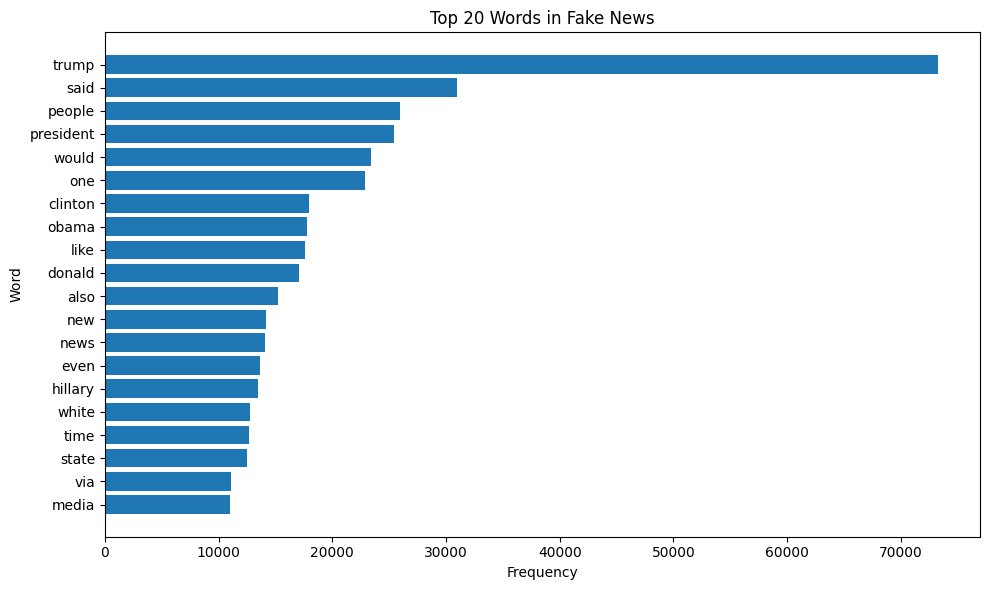

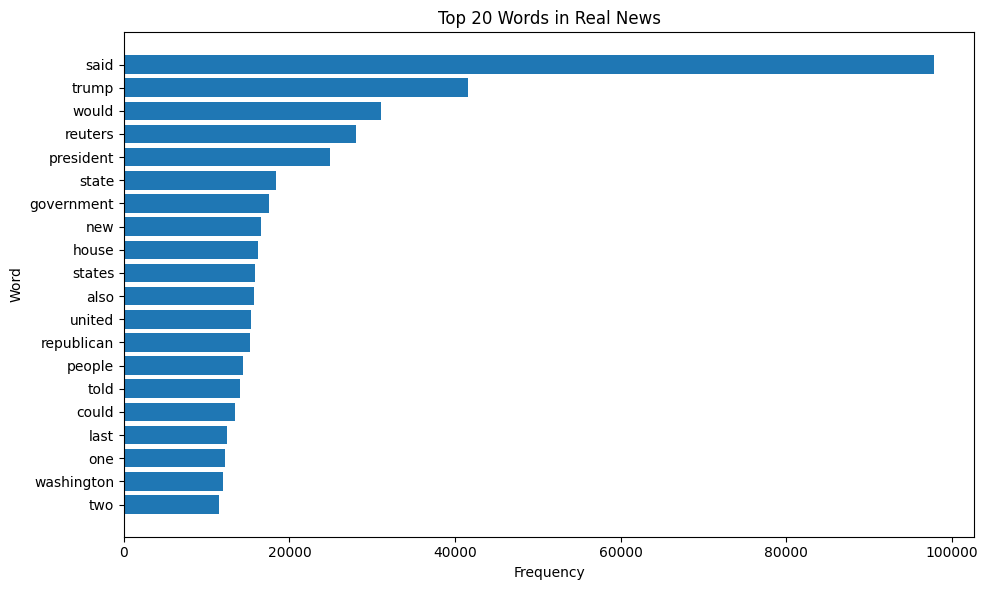

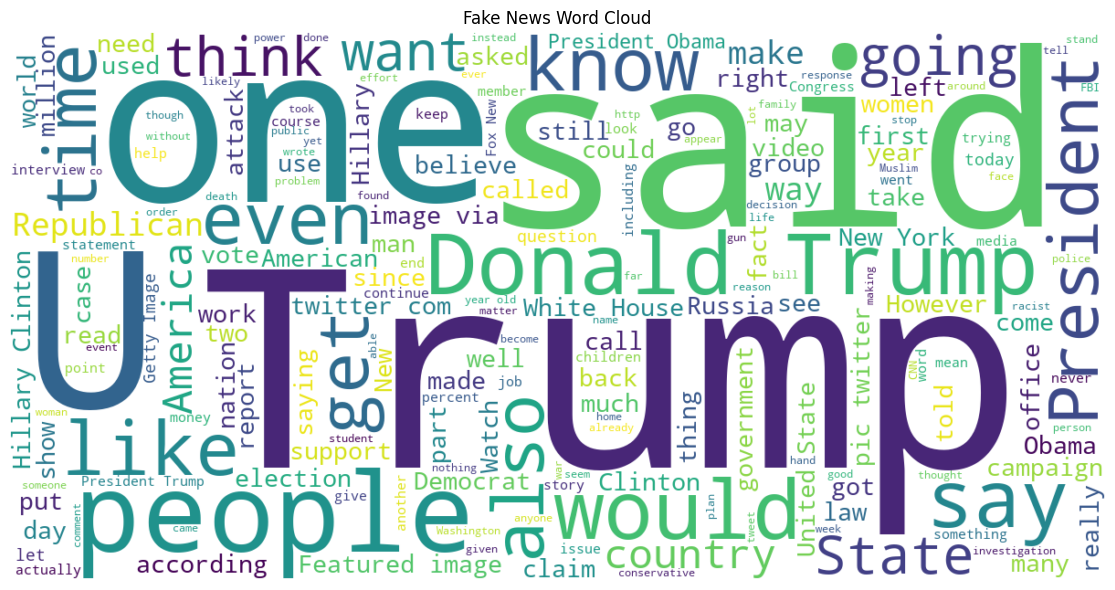

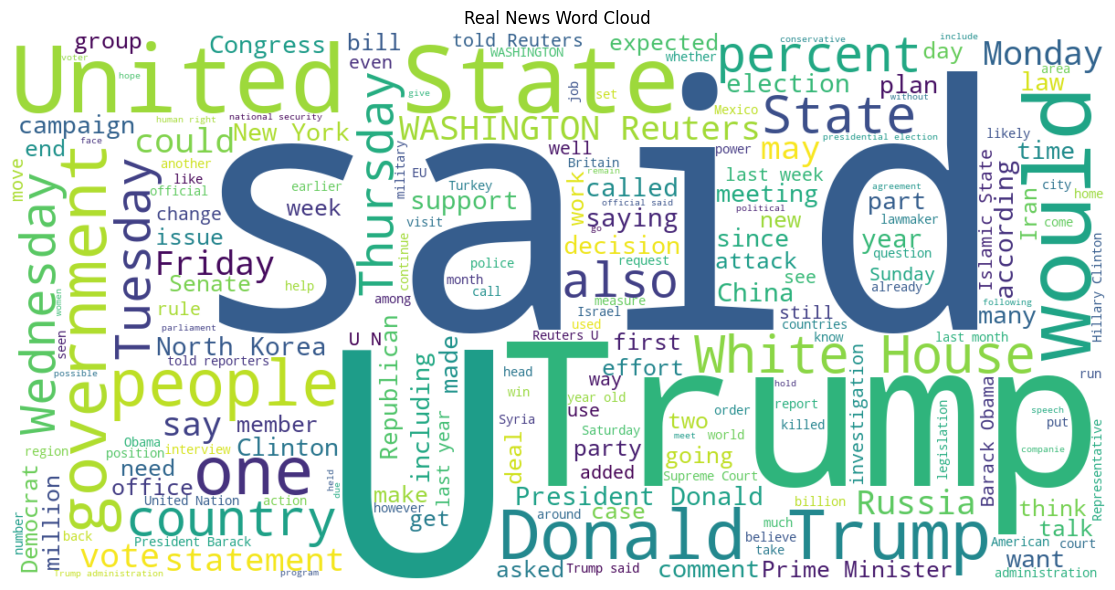

FINAL EDA SUMMARY
           title_char_count  title_word_count  text_char_count  word_count  \
Fake News         94.194054         14.732388      2547.555882  423.224167   
Real News         64.658291          9.951582      2378.042337  384.757484   

           exclamation_count  question_count  uppercase_ratio  
Fake News           0.722847        1.205682         0.057309  
Real News           0.062090        0.100325         0.052020  
FINAL DATASET INFORMATION
Final Dataset Shape: (44689, 14)
Fake News Records: 23478
Real News Records: 21211
Duplicate Records: 4
Missing Values:
title                    0
text                     0
subject                  0
date                 32821
label                    0
year                 32821
month                32821
title_char_count         0
title_word_count         0
text_char_count          0
word_count               0
exclamation_count        0
question_count           0
uppercase_ratio          0
dtype: int64
EDA COMPLETED SUCC

In [38]:


fake_words = get_top_words(
    df[
        df["label"] == 0
    ]["text"],
    n=20
)


print(
    fake_words
)



real_words = get_top_words(
    df[
        df["label"] == 1
    ]["text"],
    n=20
)




print(
    real_words
)


fake_word_df = pd.DataFrame(
    fake_words,
    columns=[
        "Word",
        "Frequency"
    ]
)


plt.figure(figsize=(10, 6))

plt.barh(
    fake_word_df["Word"][::-1],
    fake_word_df["Frequency"][::-1]
)

plt.title(
    "Top 20 Words in Fake News"
)

plt.xlabel(
    "Frequency"
)

plt.ylabel(
    "Word"
)

plt.tight_layout()
plt.show()



real_word_df = pd.DataFrame(
    real_words,
    columns=[
        "Word",
        "Frequency"
    ]
)


plt.figure(figsize=(10, 6))

plt.barh(
    real_word_df["Word"][::-1],
    real_word_df["Frequency"][::-1]
)

plt.title(
    "Top 20 Words in Real News"
)

plt.xlabel(
    "Frequency"
)

plt.ylabel(
    "Word"
)

plt.tight_layout()
plt.show()


fake_text = " ".join(
    df[
        df["label"] == 0
    ]["text"]
    .astype(str)
)


if len(fake_text.strip()) > 0:

    wc_fake = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stop_words,
        max_words=200
    ).generate(fake_text)


    plt.figure(
        figsize=(12, 6)
    )

    plt.imshow(
        wc_fake,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        "Fake News Word Cloud"
    )

    plt.tight_layout()
    plt.show()



real_text = " ".join(
    df[
        df["label"] == 1
    ]["text"]
    .astype(str)
)


if len(real_text.strip()) > 0:

    wc_real = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        stopwords=stop_words,
        max_words=200
    ).generate(real_text)


    plt.figure(
        figsize=(12, 6)
    )

    plt.imshow(
        wc_real,
        interpolation="bilinear"
    )

    plt.axis("off")

    plt.title(
        "Real News Word Cloud"
    )

    plt.tight_layout()
    plt.show()




eda_summary = (
    df.groupby("label")
    [
        [
            "title_char_count",
            "title_word_count",
            "text_char_count",
            "word_count",
            "exclamation_count",
            "question_count",
            "uppercase_ratio"
        ]
    ]
    .mean()
)


# Rename index
eda_summary.index = [
    "Fake News",
    "Real News"
]



print("FINAL EDA SUMMARY")


print(
    eda_summary
)




eda_summary.to_csv(
    "eda_summary.csv"
)


# ============================================================
# 45. SAVE PROCESSED DATASET
# ============================================================

df.to_csv(
    "fake_news_eda_processed.csv",
    index=False
)




print("FINAL DATASET INFORMATION")


print(
    "Final Dataset Shape:",
    df.shape
)

print(
    "Fake News Records:",
    (df["label"] == 0).sum()
)

print(
    "Real News Records:",
    (df["label"] == 1).sum()
)

print(
    "Duplicate Records:",
    df.duplicated().sum()
)

print(
    "Missing Values:"
)

print(
    df.isnull().sum()
)




print("EDA COMPLETED SUCCESSFULLY")


print(
    "\nProcessed dataset saved at:"
)

print(
    "fake_news_eda_processed.csv"
)

print(
    "\nEDA summary saved at:"
)

print(
    "eda_summary.csv"
)

# PHASE 2 — FEATURE ENGINEERING

## IMPORT LIBRARIES

In [39]:

!pip install -q textstat
!pip install textblob




import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk

from sklearn.feature_extraction.text import TfidfVectorizer

from nltk.sentiment import SentimentIntensityAnalyzer
from nltk.corpus import stopwords

from textblob import TextBlob
import textstat

import sys
!{sys.executable} -m pip install spacy

import spacy


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


##  DOWNLOAD NLTK RESOURCES

In [40]:

nltk.download("vader_lexicon", quiet=True)
nltk.download("stopwords", quiet=True)


True

## LOAD SPACY MODEL

In [41]:
# If model is not installed, run:
!python -m spacy download en_core_web_sm

nlp = spacy.load(
    "en_core_web_sm",
    disable=["tagger", "parser", "lemmatizer"]
)




[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     --------------------------------------- 0.0/12.8 MB 326.8 kB/s eta 0:00:40
      --------------------------------------- 0.3/12.8 MB 1.9 MB/s eta 0:00:07
     ------- -------------------------------- 2.5/12.8 MB 14.8 MB/s eta 0:00:01
     ----------- ---------------------------- 3.8/12.8 MB 18.8 MB/s eta 0:00:01
     ------------------------- -------------- 8.1/12.8 MB 28.9 MB/s eta 0:00:01
     -------------------------------- ------ 10.7/12.8 MB 54.7 MB/s eta 0:00:01
     --------------------------------------  12.8/12.8 MB 59.8 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 54.7 MB/s eta 0:00:00
[+] Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


##  PREPARE DATA

In [42]:


df["title"] = df["title"].fillna("").astype(str)
df["text"] = df["text"].fillna("").astype(str)

df["combined_text"] = (
    df["title"] + " " + df["text"]
)


print("PHASE 2 — FEATURE ENGINEERING")


print("Dataset Shape:", df.shape)


PHASE 2 — FEATURE ENGINEERING
Dataset Shape: (44689, 15)


### PART A — TF-IDF

In [43]:


print("\nCalculating TF-IDF Features...")




title_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_title_tfidf = title_tfidf.fit_transform(
    df["title"]
)

print(
    "Title TF-IDF Shape:",
    X_title_tfidf.shape
)




body_tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=10000,
    sublinear_tf=True
)

X_body_tfidf = body_tfidf.fit_transform(
    df["text"]
)

print(
    "Body TF-IDF Shape:",
    X_body_tfidf.shape
)



Calculating TF-IDF Features...
Title TF-IDF Shape: (44689, 10000)
Body TF-IDF Shape: (44689, 10000)


### PART B — VADER SENTIMENT

In [44]:

print("\nCalculating VADER Sentiment...")

sia = SentimentIntensityAnalyzer()

vader_scores = df["combined_text"].apply(
    sia.polarity_scores
)

df["vader_positive"] = vader_scores.apply(
    lambda x: x["pos"]
)

df["vader_negative"] = vader_scores.apply(
    lambda x: x["neg"]
)

df["vader_neutral"] = vader_scores.apply(
    lambda x: x["neu"]
)

df["vader_compound"] = vader_scores.apply(
    lambda x: x["compound"]
)



Calculating VADER Sentiment...


### PART C — TEXTBLOB SENTIMENT

In [45]:


print("Calculating TextBlob Features...")


df["textblob_polarity"] = (
    df["combined_text"]
    .apply(
        lambda x: TextBlob(x).sentiment.polarity
    )
)


df["textblob_subjectivity"] = (
    df["combined_text"]
    .apply(
        lambda x: TextBlob(x).sentiment.subjectivity
    )
)



Calculating TextBlob Features...


### PART D — READABILITY

In [46]:


print("Calculating Readability Features...")


df["flesch_kincaid_grade"] = (
    df["combined_text"]
    .apply(
        textstat.flesch_kincaid_grade
    )
)


df["gunning_fog"] = (
    df["combined_text"]
    .apply(
        textstat.gunning_fog
    )
)


Calculating Readability Features...


### PART E — STYLOMETRIC FEATURES

In [47]:

print("Calculating Stylometric Features...")


stop_words = set(
    stopwords.words("english")
)


def get_stylometric_features(text):

    text = str(text)

    words = text.split()

    word_count = len(words)

    # Unique Word Ratio
    if word_count > 0:

        unique_word_ratio = (
            len(
                set(
                    word.lower()
                    for word in words
                )
            )
            / word_count
        )

    else:

        unique_word_ratio = 0


    # Average Word Length
    valid_words = [
        word.strip(
            ".,!?;:\"'()[]{}"
        )
        for word in words
        if word.strip(
            ".,!?;:\"'()[]{}"
        ).isalpha()
    ]


    if valid_words:

        avg_word_length = np.mean(
            [
                len(word)
                for word in valid_words
            ]
        )

    else:

        avg_word_length = 0


    # Uppercase Ratio
    letters = [
        c for c in text
        if c.isalpha()
    ]

    if letters:

        uppercase_ratio = (
            sum(
                c.isupper()
                for c in letters
            )
            / len(letters)
        )

    else:

        uppercase_ratio = 0


    # Punctuation
    exclamation_count = text.count("!")

    question_count = text.count("?")


    # Stopword Density
    if word_count > 0:

        stopword_count = sum(
            word.lower().strip(
                ".,!?;:\"'()[]{}"
            )
            in stop_words
            for word in words
        )

        stopword_density = (
            stopword_count
            / word_count
        )

    else:

        stopword_density = 0


    return pd.Series({

        "fe_word_count":
            word_count,

        "unique_word_ratio":
            unique_word_ratio,

        "avg_word_length":
            avg_word_length,

        "fe_uppercase_ratio":
            uppercase_ratio,

        "fe_exclamation_count":
            exclamation_count,

        "fe_question_count":
            question_count,

        "stopword_density":
            stopword_density

    })


stylometric_results = (
    df["combined_text"]
    .apply(get_stylometric_features)
)


df = pd.concat(
    [
        df,
        stylometric_results
    ],
    axis=1
)


Calculating Stylometric Features...


### PART F — NAMED ENTITY RECOGNITION

In [48]:


print("\nCalculating Named Entity Features...")
print("Using optimized NER processing...")

# Keep only the NER component
nlp.select_pipes(enable=["ner"])


# Make sure there are no missing values
df["ner_text"] = df["combined_text"].fillna("").astype(str)


# Limit text length to make NER much faster
# 5000 characters is usually enough for these features
df["ner_text"] = df["ner_text"].str[:5000]


def count_entities(doc):

    person = 0
    org = 0
    gpe = 0

    for ent in doc.ents:

        if ent.label_ == "PERSON":
            person += 1

        elif ent.label_ == "ORG":
            org += 1

        elif ent.label_ == "GPE":
            gpe += 1

    return person, org, gpe


ner_results = []


for doc in nlp.pipe(
    df["ner_text"],
    batch_size=100
):

    ner_results.append(count_entities(doc))


# Convert results into DataFrame
ner_df = pd.DataFrame(
    ner_results,
    columns=[
        "person_entity_count",
        "org_entity_count",
        "gpe_entity_count"
    ],
    index=df.index
)


# Add features to original dataframe
df = pd.concat(
    [
        df,
        ner_df
    ],
    axis=1
)


# Remove temporary column
df.drop(columns=["ner_text"], inplace=True)


print("\nNER features successfully created!")

print(
    df[
        [
            "person_entity_count",
            "org_entity_count",
            "gpe_entity_count"
        ]
    ].head()
)


Calculating Named Entity Features...
Using optimized NER processing...

NER features successfully created!
   person_entity_count  org_entity_count  gpe_entity_count
0                   20                 8                 5
1                   18                 8                 4
2                   22                12                 3
3                   16                19                 5
4                   19                 3                 5


### PART G — FEATURE LIST

In [49]:


feature_columns = [

    # VADER
    "vader_positive",
    "vader_negative",
    "vader_neutral",
    "vader_compound",

    # TextBlob
    "textblob_polarity",
    "textblob_subjectivity",

    # Readability
    "flesch_kincaid_grade",
    "gunning_fog",

    # Stylometry
    "fe_word_count",
    "unique_word_ratio",
    "avg_word_length",
    "fe_uppercase_ratio",
    "fe_exclamation_count",
    "fe_question_count",
    "stopword_density",

    # NER
    "person_entity_count",
    "org_entity_count",
    "gpe_entity_count"

]

### PART H — FEATURE SUMMARY

In [50]:



print("PHASE 2 FEATURE SUMMARY")


print(
    "Number of Numerical Features:",
    len(feature_columns)
)

print("\nFeature Names:")

for i, feature in enumerate(
    feature_columns,
    1
):

    print(
        i,
        feature
    )

PHASE 2 FEATURE SUMMARY
Number of Numerical Features: 18

Feature Names:
1 vader_positive
2 vader_negative
3 vader_neutral
4 vader_compound
5 textblob_polarity
6 textblob_subjectivity
7 flesch_kincaid_grade
8 gunning_fog
9 fe_word_count
10 unique_word_ratio
11 avg_word_length
12 fe_uppercase_ratio
13 fe_exclamation_count
14 fe_question_count
15 stopword_density
16 person_entity_count
17 org_entity_count
18 gpe_entity_count


### PART I — FEATURE STATISTICS BY CLASS

In [51]:


feature_summary = (
    df.groupby("label")
    [feature_columns]
    .mean()
)



print("FEATURE STATISTICS BY CLASS")


print(
    feature_summary
)


FEATURE STATISTICS BY CLASS
       vader_positive  vader_negative  vader_neutral  vader_compound  \
label                                                                  
0            0.093008        0.101713       0.805284       -0.109154   
1            0.081896        0.078892       0.839206        0.054736   

       textblob_polarity  textblob_subjectivity  flesch_kincaid_grade  \
label                                                                   
0               0.056892               0.452130             11.617872   
1               0.053836               0.360995             13.287009   

       gunning_fog  fe_word_count  unique_word_ratio  avg_word_length  \
label                                                                   
0        14.232543     437.956555           0.611971         4.700333   
1        16.061549     394.709066           0.611781         5.055510   

       fe_uppercase_ratio  fe_exclamation_count  fe_question_count  \
label                      

### PART J — SENTIMENT ANALYSIS

In [52]:


sentiment_columns = [

    "vader_positive",
    "vader_negative",
    "vader_neutral",
    "vader_compound",

    "textblob_polarity",
    "textblob_subjectivity"

]


sentiment_by_class = (
    df.groupby("label")
    [sentiment_columns]
    .mean()
)


print("\nSentiment Features by Class:")

print(
    sentiment_by_class
)



Sentiment Features by Class:
       vader_positive  vader_negative  vader_neutral  vader_compound  \
label                                                                  
0            0.093008        0.101713       0.805284       -0.109154   
1            0.081896        0.078892       0.839206        0.054736   

       textblob_polarity  textblob_subjectivity  
label                                            
0               0.056892               0.452130  
1               0.053836               0.360995  


### PART K — READABILITY ANALYSIS

In [53]:


readability_columns = [

    "flesch_kincaid_grade",
    "gunning_fog"

]


readability_by_class = (
    df.groupby("label")
    [readability_columns]
    .mean()
)


print("\nReadability Features by Class:")

print(
    readability_by_class
)



Readability Features by Class:
       flesch_kincaid_grade  gunning_fog
label                                   
0                 11.617872    14.232543
1                 13.287009    16.061549


### PART L — STYLOMETRIC ANALYSIS

In [54]:


stylometry_columns = [

    "fe_word_count",
    "unique_word_ratio",
    "avg_word_length",
    "fe_uppercase_ratio",
    "fe_exclamation_count",
    "fe_question_count",
    "stopword_density"

]


stylometry_by_class = (
    df.groupby("label")
    [stylometry_columns]
    .mean()
)


print("\nStylometric Features by Class:")

print(
    stylometry_by_class
)



Stylometric Features by Class:
       fe_word_count  unique_word_ratio  avg_word_length  fe_uppercase_ratio  \
label                                                                          
0         437.956555           0.611971         4.700333            0.090882   
1         394.709066           0.611781         5.055510            0.052357   

       fe_exclamation_count  fe_question_count  stopword_density  
label                                                             
0                  0.876352           1.279794          0.423530  
1                  0.062986           0.106926          0.374714  


### PART M — NER ANALYSIS

In [55]:


ner_columns = [

    "person_entity_count",
    "org_entity_count",
    "gpe_entity_count"

]


ner_by_class = (
    df.groupby("label")
    [ner_columns]
    .mean()
)


print("\nNamed Entity Features by Class:")

print(
    ner_by_class
)



Named Entity Features by Class:
       person_entity_count  org_entity_count  gpe_entity_count
label                                                         
0                11.655465          9.156998          4.688517
1                 8.850974         11.271746         10.842157


### PART N — VISUALIZATIONS

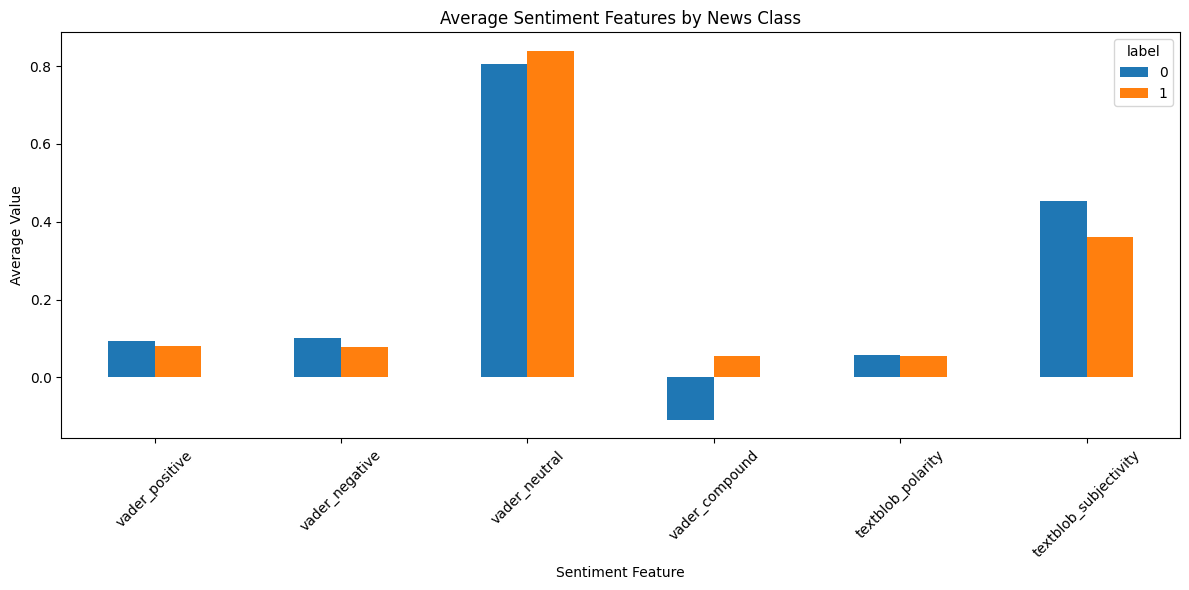

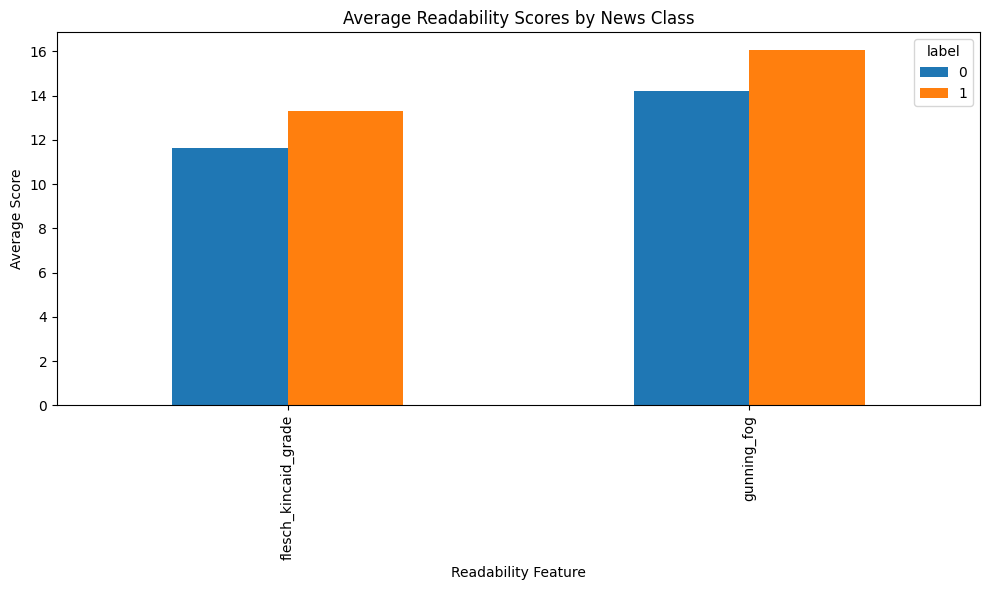

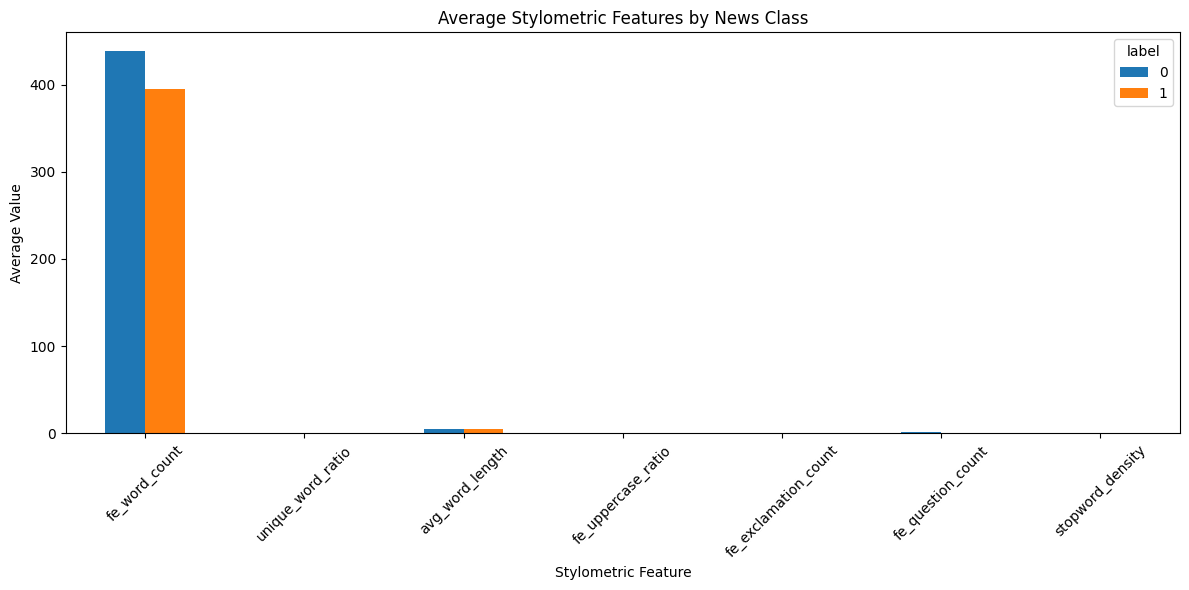

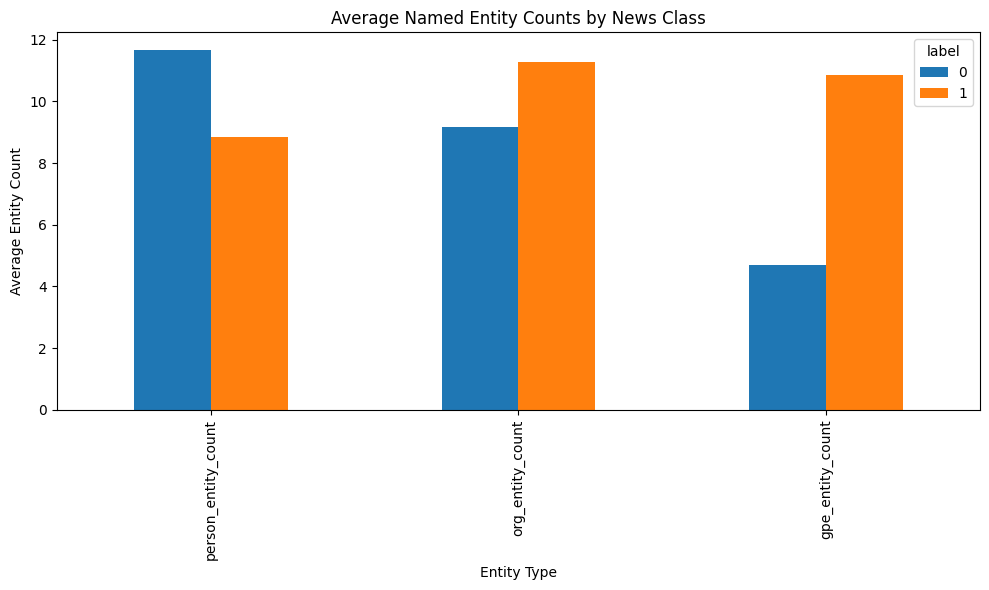

In [56]:


sentiment_by_class.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Average Sentiment Features by News Class"
)

plt.xlabel(
    "Sentiment Feature"
)

plt.ylabel(
    "Average Value"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()




readability_by_class.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Average Readability Scores by News Class"
)

plt.xlabel(
    "Readability Feature"
)

plt.ylabel(
    "Average Score"
)

plt.tight_layout()

plt.show()




stylometry_by_class.T.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Average Stylometric Features by News Class"
)

plt.xlabel(
    "Stylometric Feature"
)

plt.ylabel(
    "Average Value"
)

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()



ner_by_class.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Average Named Entity Counts by News Class"
)

plt.xlabel(
    "Entity Type"
)

plt.ylabel(
    "Average Entity Count"
)

plt.tight_layout()

plt.show()

### PART O — SAVE ENGINEERED DATASET

In [57]:
df.to_csv(
    "fake_news_feature_engineered.csv",
    index=False
)


### PART P — SAVE NUMERICAL FEATURES

In [58]:
final_features = df[
    feature_columns + ["label"]
]


final_features.to_csv(
    "fake_news_numerical_features.csv",
    index=False
)


### PART Q — SAVE FEATURE SUMMARY

In [59]:
feature_summary.to_csv(
    "feature_statistics_by_class.csv"
)


## FINAL OUTPUT

In [60]:



print(
    "PHASE 2 — FEATURE ENGINEERING COMPLETED SUCCESSFULLY"
)



print(
    "\nDataset Shape:",
    df.shape
)

print(
    "Title TF-IDF Matrix:",
    X_title_tfidf.shape
)

print(
    "Body TF-IDF Matrix:",
    X_body_tfidf.shape
)

print(
    "Numerical Engineered Features:",
    len(feature_columns)
)


print("\nSaved Files:")

print(
    "1. fake_news_feature_engineered.csv"
)

print(
    "2. fake_news_numerical_features.csv"
)

print(
    "3. feature_statistics_by_class.csv"
)

print(
    "\nPhase 2 Completed Successfully!")

PHASE 2 — FEATURE ENGINEERING COMPLETED SUCCESSFULLY

Dataset Shape: (44689, 33)
Title TF-IDF Matrix: (44689, 10000)
Body TF-IDF Matrix: (44689, 10000)
Numerical Engineered Features: 18

Saved Files:
1. fake_news_feature_engineered.csv
2. fake_news_numerical_features.csv
3. feature_statistics_by_class.csv

Phase 2 Completed Successfully!


<h2><b>Model Training & Evaluation

# PHASE 3 — MODEL TRAINING & EVALUATION

## 1. IMPORT LIBRARIES

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.sparse import hstack, csr_matrix

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import MultinomialNB

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

%pip install xgboost
from xgboost import XGBClassifier


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. SETTINGS AND LOAD DATA

In [62]:


RANDOM_STATE = 42

N_SPLITS = 5


df = pd.read_csv(
    "fake_news_feature_engineered.csv"
)




print("PHASE 3 — MODEL TRAINING & EVALUATION")



print(
    "\nOriginal Dataset Shape:",
    df.shape
)


PHASE 3 — MODEL TRAINING & EVALUATION

Original Dataset Shape: (44689, 33)


C:\Users\DELL\AppData\Local\Temp\ipykernel_2716\3141688061.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## 4. FIX LABELS

In [63]:
print("\nOriginal Labels:")

print(
    df["label"].unique()
)


# ------------------------------------------------------------
# Convert Fake / Real to 0 / 1
# If labels are already numeric, keep them unchanged
# ------------------------------------------------------------

if df["label"].dtype == "object":

    df["label"] = (

        df["label"]

        .astype(str)

        .str.strip()

        .str.lower()

        .map({

            "fake": 0,

            "real": 1

        })

    )


# Convert labels to numeric

df["label"] = pd.to_numeric(

    df["label"],

    errors="coerce"

)


# Remove invalid labels

df = df.dropna(

    subset=["label"]

)


# Convert to integer

df["label"] = df["label"].astype(int)


# Target variable

y = df["label"]


print("\nFinal Labels:")

print(
    sorted(
        y.unique()
    )
)


print("\nClass Distribution:")

print(
    y.value_counts()
)


Original Labels:
[0 1]

Final Labels:
[np.int64(0), np.int64(1)]

Class Distribution:
label
0    23478
1    21211
Name: count, dtype: int64


## 5. PREPARE TEXT

In [64]:

df["combined_text"] = (

    df["combined_text"]

    .fillna("")

    .astype(str)

)



## 6. TF-IDF FEATURE EXTRACTION

In [65]:
print("CREATING TF-IDF FEATURES")




tfidf = TfidfVectorizer(

    ngram_range=(1, 2),

    max_features=10000,

    sublinear_tf=True,

    stop_words="english"

)


X_tfidf = tfidf.fit_transform(

    df["combined_text"]

)


print(

    "TF-IDF Matrix Shape:",

    X_tfidf.shape

)


print(

    "Total TF-IDF Features:",

    len(

        tfidf.get_feature_names_out()

    )

)


CREATING TF-IDF FEATURES
TF-IDF Matrix Shape: (44689, 10000)
Total TF-IDF Features: 10000


## 7. NUMERICAL FEATURES

In [66]:


numerical_features = [

    "vader_positive",

    "vader_negative",

    "vader_neutral",

    "vader_compound",

    "fe_word_count",

    "fe_char_count",

    "unique_word_ratio",

    "avg_word_length",

    "fe_uppercase_ratio",

    "fe_exclamation_count",

    "fe_question_count",

    "stopword_density"

]


# Check available features

available_features = [

    feature

    for feature in numerical_features

    if feature in df.columns

]


print(

    "\nNumerical Features Found:",

    len(available_features)

)


print(

    available_features

)


Numerical Features Found: 11
['vader_positive', 'vader_negative', 'vader_neutral', 'vader_compound', 'fe_word_count', 'unique_word_ratio', 'avg_word_length', 'fe_uppercase_ratio', 'fe_exclamation_count', 'fe_question_count', 'stopword_density']


## 8. PREPARE NUMERICAL FEATURES

In [67]:


X_numeric = (

    df[available_features]

    .replace(

        [np.inf, -np.inf],

        np.nan

    )

    .fillna(0)

)

## 9. SCALE NUMERICAL FEATURES

In [68]:


scaler = StandardScaler()


X_numeric_scaled = scaler.fit_transform(

    X_numeric

)


# Convert to sparse matrix

X_numeric_sparse = csr_matrix(

    X_numeric_scaled

)

## 10. COMBINE TF-IDF + NUMERICAL FEATURES

In [69]:


X = hstack(

    [

        X_tfidf,

        X_numeric_sparse

    ]

).tocsr()


print(

    "\nFinal Combined Feature Matrix:",

    X.shape

)


Final Combined Feature Matrix: (44689, 10011)


## 11. DEFINE MODELS

In [70]:


models = {

    "Logistic Regression":

        LogisticRegression(

            max_iter=500,

            random_state=RANDOM_STATE

        ),


    "Multinomial Naive Bayes":

        MultinomialNB(),


    "Random Forest":

        RandomForestClassifier(

            n_estimators=200,

            random_state=RANDOM_STATE,

            n_jobs=-1

        ),


    "XGBoost":

        XGBClassifier(

            n_estimators=200,

            max_depth=6,

            learning_rate=0.1,

            random_state=RANDOM_STATE,

            eval_metric="logloss",

            n_jobs=-1

        )

}

## 12. CROSS-VALIDATION

In [71]:

cv = StratifiedKFold(

    n_splits=N_SPLITS,

    shuffle=True,

    random_state=RANDOM_STATE

)


## 13. EVALUATION METRICS

In [72]:


scoring = {

    "accuracy":

        "accuracy",


    "precision":

        "precision_macro",


    "recall":

        "recall_macro",


    "f1_macro":

        "f1_macro",


    "f1_weighted":

        "f1_weighted",


    "roc_auc":

        "roc_auc"

}

## 14. TRAIN AND EVALUATE MODELS

In [73]:
results = []


for model_name, model in models.items():




    print(

        "TRAINING:",

        model_name

    )


TRAINING: Logistic Regression
TRAINING: Multinomial Naive Bayes
TRAINING: Random Forest
TRAINING: XGBoost


In [74]:


    if (

        model_name

        ==

        "Multinomial Naive Bayes"

    ):

        X_model = X_tfidf


    else:

        X_model = X


    # --------------------------------------------------------
    # Cross Validation
    # --------------------------------------------------------

    scores = cross_validate(

        model,

        X_model,

        y,

        cv=cv,

        scoring=scoring,

        n_jobs=-1,

        return_train_score=False,

        error_score="raise"

    )


    # --------------------------------------------------------
    # Calculate Average Scores
    # --------------------------------------------------------

    accuracy = (

        scores[

            "test_accuracy"

        ]

        .mean()

    )


    precision = (

        scores[

            "test_precision"

        ]

        .mean()

    )


    recall = (

        scores[

            "test_recall"

        ]

        .mean()

    )


    f1_macro = (

        scores[

            "test_f1_macro"

        ]

        .mean()

    )


    f1_weighted = (

        scores[

            "test_f1_weighted"

        ]

        .mean()

    )


    roc_auc = (

        scores[

            "test_roc_auc"

        ]

        .mean()

    )


    # --------------------------------------------------------
    # Store Results
    # --------------------------------------------------------

    results.append({

        "Model":

            model_name,

        "Accuracy":

            accuracy,

        "Precision":

            precision,

        "Recall":

            recall,

        "F1 Macro":

            f1_macro,

        "F1 Weighted":

            f1_weighted,

        "AUC-ROC":

            roc_auc

    })


    # --------------------------------------------------------
    # Print Results
    # --------------------------------------------------------

    print(

        "Accuracy:",

        round(

            accuracy,

            4

        )

    )


    print(

        "Precision:",

        round(

            precision,

            4

        )

    )


    print(

        "Recall:",

        round(

            recall,

            4

        )

    )


    print(

        "F1 Macro:",

        round(

            f1_macro,

            4

        )

    )


    print(

        "F1 Weighted:",

        round(

            f1_weighted,

            4

        )

    )


    print(

        "AUC-ROC:",

        round(

            roc_auc,

            4

        )

    )


Accuracy: 0.9984
Precision: 0.9984
Recall: 0.9984
F1 Macro: 0.9984
F1 Weighted: 0.9984
AUC-ROC: 0.9999


## 15. MODEL COMPARISON

In [75]:


results_df = pd.DataFrame(

    results

)


# Sort by F1 Macro

results_df = (

    results_df

    .sort_values(

        by="F1 Macro",

        ascending=False

    )

    .reset_index(

        drop=True

    )

)




print(

    "MODEL COMPARISON RESULTS"

)



print(

    results_df.to_string(

        index=False

    )

)


MODEL COMPARISON RESULTS
  Model  Accuracy  Precision   Recall  F1 Macro  F1 Weighted  AUC-ROC
XGBoost  0.998411   0.998409 0.998406  0.998407     0.998411 0.999933


## 16. SAVE MODEL RESULTS

In [76]:

results_df.to_csv(

    "phase3_model_results.csv",

    index=False

)


## 17. MODEL PERFORMANCE GRAPH

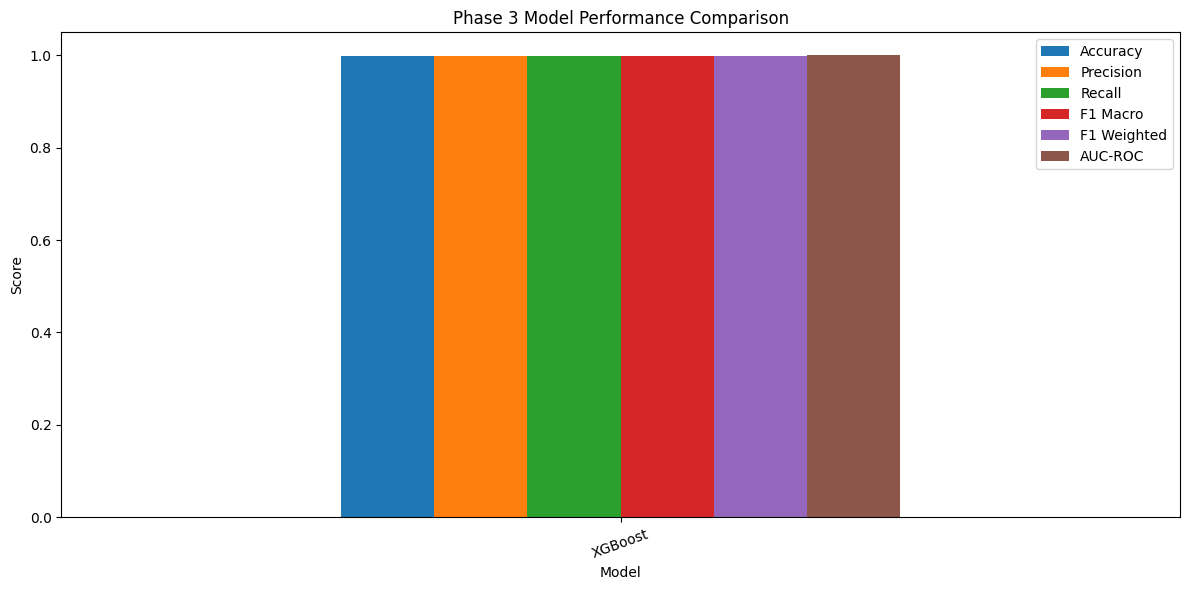

In [77]:


results_df.set_index(

    "Model"

)[

    [

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Macro",

        "F1 Weighted",

        "AUC-ROC"

    ]

].plot(

    kind="bar",

    figsize=(12, 6)

)


plt.title(

    "Phase 3 Model Performance Comparison"

)


plt.ylabel(

    "Score"

)


plt.ylim(

    0,

    1.05

)


plt.xticks(

    rotation=20

)


plt.tight_layout()


plt.show()

## 18. SELECT TOP 2 MODELS

In [78]:


top_models = (

    results_df

    .head(2)

    ["Model"]

    .tolist()

)


print(

    "\nTop 2 Performing Models:"

)


for model_name in top_models:

    print(

        "✓",

        model_name

    )



Top 2 Performing Models:
✓ XGBoost


# 19. SIMPLE GRID SEARCH

In [79]:


param_grids = {


    "Logistic Regression":

    {

        "C":

        [

            0.1,

            1,

            10

        ]

    },


    "Random Forest":

    {

        "max_depth":

        [

            None,

            20

        ],


        "min_samples_split":

        [

            2,

            5

        ]

    },


    "XGBoost":

    {

        "max_depth":

        [

            3,

            6

        ],


        "learning_rate":

        [

            0.1

        ]

    },


    "Multinomial Naive Bayes":

    {

        "alpha":

        [

            0.1,

            1.0

        ]

    }

}


## 20. TUNE TOP MODELS

In [80]:


tuned_results = []

best_models = {}


for model_name in top_models:



    print(

        "GRID SEARCH:",

        model_name

    )




    # Get model

    model = models[

        model_name

    ]


    # Select correct features

    if (

        model_name

        ==

        "Multinomial Naive Bayes"

    ):

        X_model = X_tfidf


    else:

        X_model = X


    # Grid Search

    grid = GridSearchCV(

        estimator=model,

        param_grid=

        param_grids[

            model_name

        ],

        scoring="f1_macro",

        cv=3,

        n_jobs=-1,

        return_train_score=False

    )


    # Fit model

    grid.fit(

        X_model,

        y

    )


    # Save best model

    best_models[

        model_name

    ] = grid.best_estimator_


    # Save results

    tuned_results.append({

        "Model":

            model_name,

        "Best F1 Macro":

            grid.best_score_

    })


    print(

        "Best Parameters:",

        grid.best_params_

    )


    print(

        "Best F1 Macro:",

        round(

            grid.best_score_,

            4

        )

    )

GRID SEARCH: XGBoost
Best Parameters: {'learning_rate': 0.1, 'max_depth': 3}
Best F1 Macro: 0.9953


## 21. TUNED MODEL RESULTS

In [81]:


tuned_results_df = pd.DataFrame(

    tuned_results

)




print(

    "TUNED MODEL RESULTS"

)



print(

    tuned_results_df.to_string(

        index=False

    )

)

TUNED MODEL RESULTS
  Model  Best F1 Macro
XGBoost       0.995334


## 22. FIND BEST FINAL MODEL

In [82]:


best_row = (

    tuned_results_df

    .sort_values(

        by="Best F1 Macro",

        ascending=False

    )

    .iloc[0]

)


best_tuned_model_name = (

    best_row["Model"]

)


best_f1_score = (

    best_row["Best F1 Macro"]

)


best_model = (

    best_models[

        best_tuned_model_name

    ]

)




print(

    "FINAL BEST MODEL"

)




print(

    "Best Model:",

    best_tuned_model_name

)


print(

    "Best F1 Macro:",

    round(

        best_f1_score,

        4

    )

)


FINAL BEST MODEL
Best Model: XGBoost
Best F1 Macro: 0.9953


## 23. TRAIN FINAL MODEL

In [83]:


print(

    "\nTraining Final Model..."

)


if (

    best_tuned_model_name

    ==

    "Multinomial Naive Bayes"

):


    best_model.fit(

        X_tfidf,

        y

    )


else:


    best_model.fit(

        X,

        y

    )


print(

    "Final Model Trained Successfully!"

)


Training Final Model...
Final Model Trained Successfully!


## 24. SAVE FINAL RESULTS

In [84]:


final_results = pd.DataFrame({

    "Best Model":

    [

        best_tuned_model_name

    ],


    "Best F1 Macro":

    [

        best_f1_score

    ]

})


final_results.to_csv(

    "final_best_model_results.csv",

    index=False

)


## 25. FINAL OUTPUT

In [85]:



print(

    "PHASE 3 — COMPLETED SUCCESSFULLY"

)




print(

    "\nDataset Shape:",

    df.shape

)


print(

    "TF-IDF Features:",

    X_tfidf.shape[1]

)


print(

    "Numerical Features:",

    len(

        available_features

    )

)


print(

    "\nBest Model:",

    best_tuned_model_name

)


print(

    "Best F1 Macro:",

    round(

        best_f1_score,

        4

    )

)


print(

    "\nSaved Files:"

)


print(

    "✓ phase3_model_results.csv"

)


print(

    "✓ final_best_model_results.csv"

)


print(

    "\nPHASE 3 COMPLETED!"
)

PHASE 3 — COMPLETED SUCCESSFULLY

Dataset Shape: (44689, 33)
TF-IDF Features: 10000
Numerical Features: 11

Best Model: XGBoost
Best F1 Macro: 0.9953

Saved Files:
✓ phase3_model_results.csv
✓ final_best_model_results.csv

PHASE 3 COMPLETED!


<h2><b>Interpretability & Insights

## PHASE 4 — INTERPRETABILITY & INSIGHTS

### 1. IMPORT LIBRARIES

In [86]:


print("PHASE 4 ANALYSIS STARTED")


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, cross_val_predict

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    accuracy_score
)


PHASE 4 ANALYSIS STARTED


### 2. PREPARE DATA

In [87]:

# Make sure labels are numeric

if df["label"].dtype == "object":

    df["label"] = (

        df["label"]

        .astype(str)

        .str.lower()

        .str.strip()

        .map({

            "fake": 0,

            "real": 1

        })

    )


df["label"] = pd.to_numeric(

    df["label"],

    errors="coerce"

)


df = df.dropna(

    subset=["label"]

)


df["label"] = df["label"].astype(int)


y = df["label"]

### 3. CREATE CROSS-VALIDATED PREDICTIONS

In [88]:

print("\nGenerating predictions...")


# XGBoost uses combined TF-IDF + numerical features

X_phase4 = X


cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)


# Generate predictions

y_pred = cross_val_predict(

    best_model,

    X_phase4,

    y,

    cv=cv,

    method="predict",

    n_jobs=-1

)


# Generate probabilities

y_prob = cross_val_predict(

    best_model,

    X_phase4,

    y,

    cv=cv,

    method="predict_proba",

    n_jobs=-1

)[:, 1]


print(

    "Predictions generated successfully!"

)


Generating predictions...
Predictions generated successfully!


### 4. OVERALL MODEL PERFORMANCE

In [89]:




print("OVERALL MODEL PERFORMANCE")


accuracy = accuracy_score(

    y,

    y_pred

)


auc_score = roc_auc_score(

    y,

    y_prob

)


print(

    "Accuracy:",

    round(

        accuracy,

        4

    )

)


print(

    "AUC-ROC:",

    round(

        auc_score,

        4

    )

)


print("\nClassification Report:")


print(

    classification_report(

        y,

        y_pred,

        target_names=[

            "Fake",

            "Real"

        ]

    )

)

OVERALL MODEL PERFORMANCE
Accuracy: 0.9982
AUC-ROC: 0.9999

Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      1.00      1.00     23478
        Real       1.00      1.00      1.00     21211

    accuracy                           1.00     44689
   macro avg       1.00      1.00      1.00     44689
weighted avg       1.00      1.00      1.00     44689



### 5. CONFUSION MATRIX


Confusion Matrix:
[[23435    43]
 [   38 21173]]


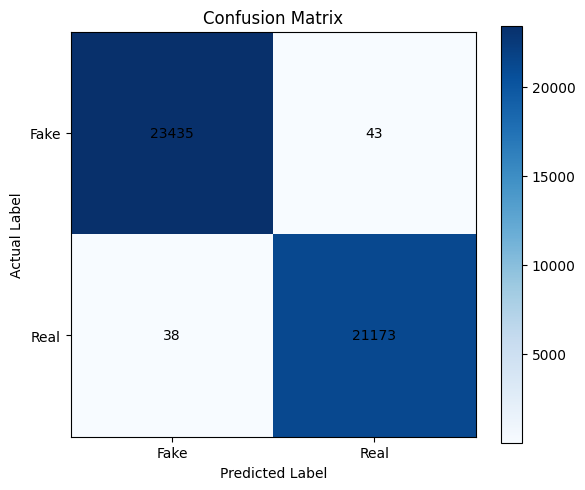

In [90]:


cm = confusion_matrix(

    y,

    y_pred

)


print("\nConfusion Matrix:")

print(cm)


plt.figure(

    figsize=(6, 5)

)


plt.imshow(

    cm,

    interpolation="nearest",
    cmap = "Blues"

)


plt.title(

    "Confusion Matrix"

)


plt.xlabel(

    "Predicted Label"

)


plt.ylabel(

    "Actual Label"

)


plt.xticks(

    [0, 1],

    ["Fake", "Real"]

)


plt.yticks(

    [0, 1],

    ["Fake", "Real"]

)


for i in range(2):

    for j in range(2):

        plt.text(

            j,

            i,

            cm[i, j],

            ha="center",

            va="center"

        )


plt.colorbar()


plt.tight_layout()


plt.show()

### 6. MISCLASSIFICATION ANALYSIS

In [91]:


df["prediction"] = y_pred

df["prediction_probability"] = y_prob


# Incorrect predictions

misclassified = df[

    df["label"]

    !=

    df["prediction"]

]




print("MISCLASSIFICATION ANALYSIS")



print(

    "Total Misclassified:",

    len(misclassified)

)


print(

    "Misclassification Rate:",

    round(

        len(misclassified) / len(df),

        4

    )

)


# Fake predicted as Real

fake_as_real = len(

    df[

        (df["label"] == 0)

        &

        (df["prediction"] == 1)

    ]

)


# Real predicted as Fake

real_as_fake = len(

    df[

        (df["label"] == 1)

        &

        (df["prediction"] == 0)

    ]

)


print(

    "Fake News predicted as Real:",

    fake_as_real

)


print(

    "Real News predicted as Fake:",

    real_as_fake

)

MISCLASSIFICATION ANALYSIS
Total Misclassified: 81
Misclassification Rate: 0.0018
Fake News predicted as Real: 43
Real News predicted as Fake: 38


### 7. SUBJECT-WISE PERFORMANCE

SUBJECT-WISE PERFORMANCE
        subject  Accuracy  Samples
       politics  0.996636   6838.0
Government News  0.996815   1570.0
   politicsNews  0.997148  11220.0
    Middle-east  0.997429    778.0
      left-news  0.998206   4459.0
        US_News  0.998723    783.0
      worldnews  0.999399   9991.0
           News  0.999558   9050.0


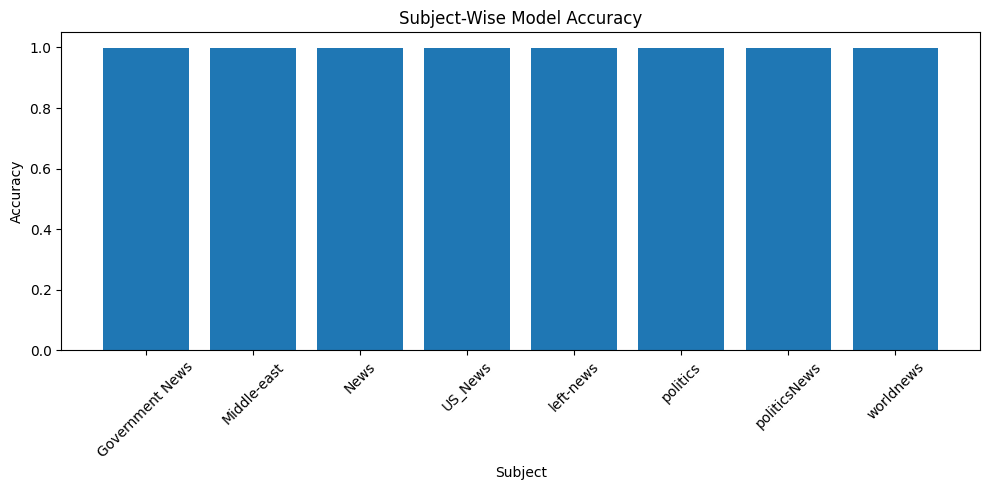

In [92]:


if "subject" in df.columns:


    print("SUBJECT-WISE PERFORMANCE")




    subject_results = (

        df

        .groupby("subject")

        .apply(

            lambda x:

            pd.Series({

                "Accuracy":

                accuracy_score(

                    x["label"],

                    x["prediction"]

                ),

                "Samples":

                len(x)

            }),

            include_groups=False

        )

        .reset_index()

    )


    print(

        subject_results

        .sort_values(

            "Accuracy"

        )

        .to_string(

            index=False

        )

    )


    # Plot

    plt.figure(

        figsize=(10, 5)

    )


    plt.bar(

        subject_results["subject"],

        subject_results["Accuracy"]

    )


    plt.title(

        "Subject-Wise Model Accuracy"

    )


    plt.xlabel(

        "Subject"

    )


    plt.ylabel(

        "Accuracy"

    )


    plt.xticks(

        rotation=45

    )


    plt.ylim(

        0,

        1.05

    )


    plt.tight_layout()


    plt.show()


else:

    print(

        "\nSubject column not available."

    )


### 8. TEMPORAL PERFORMANCE ANALYSIS

TEMPORAL PERFORMANCE ANALYSIS
  year  Accuracy  Samples
2015.0  0.997041    338.0
2016.0  0.999293   7077.0
2017.0  0.998877   4453.0


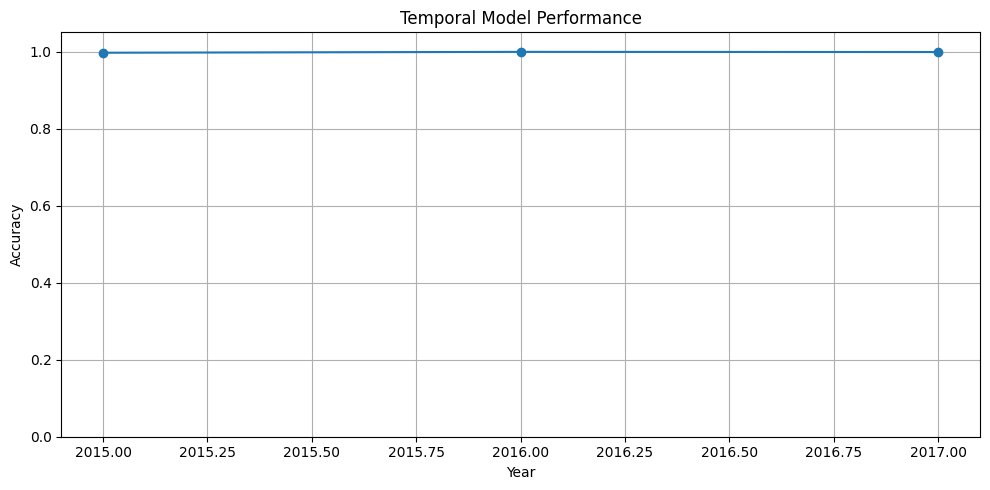

In [93]:


if "date" in df.columns:

    print("TEMPORAL PERFORMANCE ANALYSIS")



    df["date"] = pd.to_datetime(

        df["date"],

        errors="coerce"

    )


    df["year"] = df["date"].dt.year


    temporal_results = (

        df

        .dropna(

            subset=["year"]

        )

        .groupby("year")

        .apply(

            lambda x:

            pd.Series({

                "Accuracy":

                accuracy_score(

                    x["label"],

                    x["prediction"]

                ),

                "Samples":

                len(x)

            }),

            include_groups=False

        )

        .reset_index()

    )


    print(

        temporal_results

        .sort_values(

            "year"

        )

        .to_string(

            index=False

        )

    )


    # Plot

    plt.figure(

        figsize=(10, 5)

    )


    plt.plot(

        temporal_results["year"],

        temporal_results["Accuracy"],

        marker="o"

    )


    plt.title(

        "Temporal Model Performance"

    )


    plt.xlabel(

        "Year"

    )


    plt.ylabel(

        "Accuracy"

    )


    plt.ylim(

        0,

        1.05

    )


    plt.grid(

        True

    )


    plt.tight_layout()


    plt.show()


else:

    print(

        "\nDate column not available."

    )


### 9. SHAP GLOBAL FEATURE IMPORTANCE

In [94]:




print("SHAP ANALYSIS")



try:

    import shap


    print(

        "Calculating SHAP importance..."

    )


    # Use a small sample for faster SHAP analysis

    sample_size = min(

        500,

        X_phase4.shape[0]

    )


    sample_indices = np.random.RandomState(

        42

    ).choice(

        X_phase4.shape[0],

        sample_size,

        replace=False

    )


    X_sample = X_phase4[

        sample_indices

    ]


    # SHAP TreeExplainer

    explainer = shap.TreeExplainer(

        best_model

    )


    shap_values = explainer.shap_values(

        X_sample

    )


    # Handle SHAP output

    if isinstance(

        shap_values,

        list

    ):

        shap_values_plot = shap_values[1]

    else:

        shap_values_plot = shap_values


    print(

        "SHAP analysis completed."

    )


    # SHAP summary plot

    shap.summary_plot(

        shap_values_plot,

        X_sample,

        feature_names=None,

        show=True

    )


except Exception as e:

    print(

        "SHAP analysis skipped:",

        str(e)

    )


SHAP ANALYSIS
SHAP analysis skipped: No module named 'shap'


### 10. LEAKAGE AUDIT

In [95]:


print("LEAKAGE AUDIT")



if "subject" in df.columns:

    print(

        "Subject column detected."

    )


    print(

        "The subject feature is NOT directly used "

        "in the numerical feature matrix."

    )


    print(

        "A separate subject-based analysis is performed "

        "to identify possible dataset bias."

    )


    print(

        "\nSubject distribution by class:"

    )


    leakage_table = pd.crosstab(

        df["subject"],

        df["label"],

        normalize="index"

    )


    print(

        leakage_table

    )


else:

    print(

        "Subject column not available."

    )

LEAKAGE AUDIT
Subject column detected.
The subject feature is NOT directly used in the numerical feature matrix.
A separate subject-based analysis is performed to identify possible dataset bias.

Subject distribution by class:
label              0    1
subject                  
Government News  1.0  0.0
Middle-east      1.0  0.0
News             1.0  0.0
US_News          1.0  0.0
left-news        1.0  0.0
politics         1.0  0.0
politicsNews     0.0  1.0
worldnews        0.0  1.0


### 11. SAVE PHASE 4 RESULTS

In [96]:

df.to_csv(

    "phase4_predictions_and_analysis.csv",

    index=False

)


subject_results.to_csv(

    "subject_wise_results.csv",

    index=False

) if "subject" in df.columns else None


if "date" in df.columns:

    temporal_results.to_csv(

        "temporal_results.csv",

        index=False

    )

### 12. FINAL OUTPUT

In [97]:

print(

    "PHASE 4 — COMPLETED SUCCESSFULLY"

)




print(

    "\nBest Model:",

    best_tuned_model_name

)


print(

    "Accuracy:",

    round(

        accuracy,

        4

    )

)


print(

    "AUC-ROC:",

    round(

        auc_score,

        4

    )

)


print(

    "Misclassified Samples:",

    len(misclassified)

)


print(

    "\nOutput Files:"

)


print(

    "✓ phase4_predictions_and_analysis.csv"

)


if "subject" in df.columns:

    print(

        "✓ subject_wise_results.csv"

    )


if "date" in df.columns:

    print(

        "✓ temporal_results.csv"

    )


print(

    "\nPHASE 4 ANALYSIS COMPLETED!"

)

PHASE 4 — COMPLETED SUCCESSFULLY

Best Model: XGBoost
Accuracy: 0.9982
AUC-ROC: 0.9999
Misclassified Samples: 81

Output Files:
✓ phase4_predictions_and_analysis.csv
✓ subject_wise_results.csv
✓ temporal_results.csv

PHASE 4 ANALYSIS COMPLETED!
